In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import * # noqa

In [34]:
# Hyperparameters
VAL_X = 2   # n. of categories of X
VAL_Y = 2   # n. of categories of Y
VAL_CX = 2   # n. of categories of C_X
VAL_CY = 2   # n. of categories of C_Y
E = 3       # n. of clients (must be > VAL_C)
N = 50      # sample size, for any client


In [35]:
class Augmented_BN:

    def __init__(self, bn: gum.BayesNet, context_vars: set = {}):

        if context_vars == {}:
            warnings.warn("No context node provided.")

        self.bn = bn
        self.context_vars = context_vars 
    
    def get_cond_bn(self, context: dict = {}):
        
        # Check whether provided context is consistent with the model
        if len(context) != len(self.context_vars):
            raise RuntimeError(f"Provided context ({len(context)} vars) does not match with model's context ({len(self.context_vars)} vars).")

        # Copy original BN
        bn_cond = gum.BayesNet(self.bn)

        # For each context variable ...
        for c_var in context.keys():

            # ... delete that node, ...
            bn_cond.erase(c_var)

            # ... and replace the CPTs of children
            for child in self.bn.children(c_var):
                bn_cond.cpt(child)[:] = self.bn.cpt(child).extract({c_var:context[c_var]})[:]

        return bn_cond

In [36]:
class Client:
    n_clients = 0

    def __init__(self, gt_aug: Augmented_BN, context: dict):
        self.label = Client.n_clients
        Client.n_clients += 1     
        
        # Set the augmented GT and context
        self._gt_aug = gt_aug
        self._context = context

        # Condition the augmented GT to get the client-specific GT
        self._gt = gt_aug.get_cond_bn(context)

        # Set other args to None
        self._data_aug = None
        self._data = None
        self._bn = None
        self._bn_counts = None
        self.cn = None
        self.ess = None


    def check(self, attributes: list):
        for a in attributes:
            if getattr(self, a) is None:
                raise RuntimeError(f"Attribute '{a}' is missing.")
        

    def generate_data(self, size: int) -> None:
    
        gen = gum.BNDatabaseGenerator(self._gt_aug.bn)
        gen.drawSamples(size, self._context)
        self._data_aug = gen.to_pandas()
        self._data = self._data_aug.drop(columns=self._context.keys())
    
    def learn_bn(self) -> None:
        '''
        Learn the BN parameters by MLE, given its structure and data.
        '''
        self.check(["_data_aug"])
        self._bn = learn_bn_params(self._gt, self._data_aug)
        

    def learn_cn(self, ess: int) -> None:
        '''
        Learn the CN by local IDM, given its structure and data.
        '''
        self.check(["_data", "_bn"])
        self._bn_counts = get_bn_counts(self._bn, self._data)
        cn = gum.CredalNet(self._bn_counts)
        cn.idmLearning(ess)

        self.ess = ess
        self.cn = cn
        
    def get_cset(self, var:str):

        self.check(["cn"])

        bn_min, bn_max = get_min_max_bns(self.cn)
        cpt_min = bn_min.cpt(var)
        cpt_max = bn_max.cpt(var)

        return cpt_min[:], cpt_max[:]
    
    def update_cset(self, var:str, prior: tuple = None) -> tuple:

        self.check(["cn"])

        if prior is None: return self.get_cset(var)
        
        prior_cpt_min = np.atleast_2d(prior[0])
        prior_cpt_max = np.atleast_2d(prior[1])
        
        cpt_mle = np.atleast_2d(self._bn.cpt(var)[:])
        cpt_counts = np.atleast_2d(self._bn_counts.cpt(var)[:])
        ess = self.ess

        new_cpt = np.zeros((2,*cpt_mle.shape))

        # For each configuration of the parents...
        for i in range(cpt_mle.shape[0]):
            row_mle = cpt_mle[i, :]
            row_min = prior_cpt_min[i, :]
            row_max = prior_cpt_max[i, :]
            
            n_pi = np.sum(cpt_counts[i, :])

            new_cpt[0, i, :] = n_pi/(n_pi + ess)*row_mle + ess/(n_pi + ess)*row_min
            new_cpt[1, i, :] = n_pi/(n_pi + ess)*row_mle + ess/(n_pi + ess)*row_max

        # Debug
        safe_assert(np.all(prior_cpt_min <= prior_cpt_max))
        safe_assert(prior_cpt_min.shape == prior_cpt_max.shape)
        safe_assert(prior_cpt_min.shape == cpt_mle.shape)
        safe_assert(prior_cpt_min.shape == cpt_counts.shape)
        safe_assert(np.all(new_cpt[0, :, :] <= cpt_mle))
        safe_assert(np.all(new_cpt[1, :, :] >= cpt_mle))
        safe_assert(np.all(self.get_cset(var)[0] <= new_cpt[0, :, :]))
        safe_assert(np.all(self.get_cset(var)[1] >= new_cpt[1, :, :]))

        return np.squeeze(new_cpt[0, ...]), np.squeeze(new_cpt[1, ...])


In [37]:
class CsetFusion():

    def __init__(self, var:str, method: str, weighting: str = None):
        self.var = var
        self.method = method
        self.weighting = weighting

    def __call__(self, clients: list):

        if len(clients) == 1: return clients[0].get_cset(self.var)
        
        # Get the CPTs
        shape = clients[0].get_cset(self.var)[0].shape
        cpts = np.zeros((2, *shape, len(clients)))  #!
        for i in range(len(clients)):
            client =clients[i]
            client.check(["cn"])
            cpt_min, cpt_max = client.get_cset(self.var)
            cpts[0, :, i] = cpt_min
            cpts[1, :, i] = cpt_max

        if self.method == "ConvComb":

            if self.weighting == "unif":
                w = 1/len(clients)
                cpts_sum = np.sum(cpts, axis=2) * w
                cpt_min, cpt_max = cpts_sum[0, ...], cpts_sum[1, ...]

                return cpt_min, cpt_max


            elif self.weighting is None:
                RuntimeError(f"Attribute 'weighting' is missing.")

            else:
                raise NotImplementedError(f"No '{self.weighting}' weighting implemented.")
            
        else:
            raise NotImplementedError(f"No '{self.method}' method implemented.")

### Example with 2 context nodes

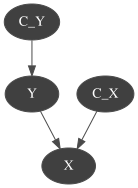

In [38]:
# Create the augmented model
set_seed()
bn_aug = Augmented_BN(gum.fastBN(f"C_X[{VAL_CX}]->X[{VAL_X}]<-Y[{VAL_Y}]<-C_Y[{VAL_CY}]"), context_vars = {"C_X", "C_Y"})

gnb.showBN(bn_aug.bn)

In [39]:
# Generate clients
clients = {}
for e in range(E):

    # Init the client
    context = {"C_X":0} |  {"C_Y":int(np.random.choice(VAL_CY, 1)[0])}
    client = Client(bn_aug, context)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

# Plot CPTs
for e in range(E):
    client = clients[e]
    print(f"Client {e}. Variables: {client._gt.names()}. Context: {client._context}. GT:")
    gnb.showCPTs(clients[e]._gt)

Client 0. Variables: {'X', 'Y'}. Context: {'C_X': 0, 'C_Y': 0}. GT:


Client 1. Variables: {'X', 'Y'}. Context: {'C_X': 0, 'C_Y': 1}. GT:


Client 2. Variables: {'X', 'Y'}. Context: {'C_X': 0, 'C_Y': 0}. GT:


In [40]:
# Check the correctness of `update_cset` function
for e in range(len(clients)):
    assert(np.all(clients[e].get_cset("Y")[0] - clients[e].update_cset("Y", [np.array([0., 0.]), np.array([1.,1.])])[0] < 1e-6))
    assert(np.all(clients[e].get_cset("X")[0] - clients[e].update_cset("X", [np.array([[0., 0.],[0., 0.]]), np.array([[1.,1.],[1.,1.]])])[0] < 1e-6))

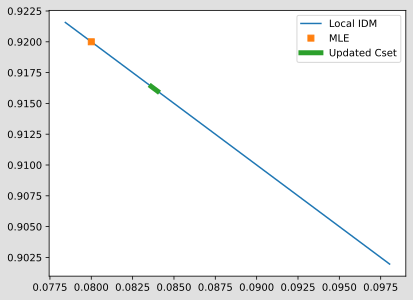


Cset CPT for Y in client 0:
 (array([0.0784314 , 0.90196103]), array([0.0980392 , 0.92156899]))
MLE CPT for Y in client 0:
 [0.08 0.92]

Prior CPT min for Y:
 [0.2647057 0.7156865]

Prior CPT max for Y:
 [0.2843136  0.73529449]

Updated Cset for Y in client 0:
 (array([0.08362168, 0.91599385]), array([0.08400615, 0.91637832]))


In [45]:
# Example
var = "Y"
c_idx = 0
fusion = CsetFusion(var, "ConvComb", "unif")
prior_clients = list(clients.values())
del prior_clients[c_idx]
cpt_min, cpt_max = fusion(prior_clients)

# Plot
cset = clients[c_idx].get_cset(var)
plt.plot([cset[0][0], cset[1][0]], [cset[1][1], cset[0][1]], "-", label="Local IDM")

mle = clients[c_idx]._bn.cpt(var)[:]
plt.plot(mle[0], mle[1], "s", label="MLE")

# prior = [cpt_min, cpt_max]
# plt.plot([prior[0][0], prior[1][0]], [prior[1][1], prior[0][1]], "-", linewidth=5, label="Prior")

cset_update = clients[c_idx].update_cset(var, prior=(cpt_min, cpt_max))
plt.plot([cset_update[0][0], cset_update[1][0]], [cset_update[1][1], cset_update[0][1]], "-", linewidth=5, label="Updated Cset")

plt.legend(loc="best")
plt.show()

# Print
print(f"\nCset CPT for {var} in client {c_idx}:\n", clients[c_idx].get_cset(var))
print(f"MLE CPT for {var} in client {c_idx}:\n", clients[c_idx]._bn.cpt(var)[:])
print(f"\nPrior CPT min for {var}:\n", cpt_min)
print(f"\nPrior CPT max for {var}:\n", cpt_max)
print(f"\nUpdated Cset for {var} in client {c_idx}:\n", clients[c_idx].update_cset(var, prior=(cpt_min, cpt_max)))